In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the dataset
df = pd.read_csv(r"C:\Users\nithish\Downloads\HR_Analytics_Project\IBM_HR_Data_Clean.csv",encoding = 'latin1')

# 2. Fixing the glitchy column name instantly
df.rename(columns={'ï»¿Age': 'Age'}, inplace=True)

print("Data loaded successfully! Total records:", len(df))

Data loaded successfully! Total records: 1470


In [3]:
# Calculating total employees and total resignations
total_employees = len(df)
total_left = df['Attrition'].value_counts()['Yes']
overall_attrition_rate = (total_left / total_employees) * 100

print(f"Total Employees: {total_employees}")
print(f"Total Resignations: {total_left}")
print(f"Overall Company Attrition Rate: {overall_attrition_rate:.2f}%\n")

# Deep Dive: Calculating attrition percentage by department
dept_breakdown = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
print("Attrition Rate (%) by Department:")
print(dept_breakdown['Yes'].round(2))

Total Employees: 1470
Total Resignations: 237
Overall Company Attrition Rate: 16.12%

Attrition Rate (%) by Department:
Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
Name: Yes, dtype: float64


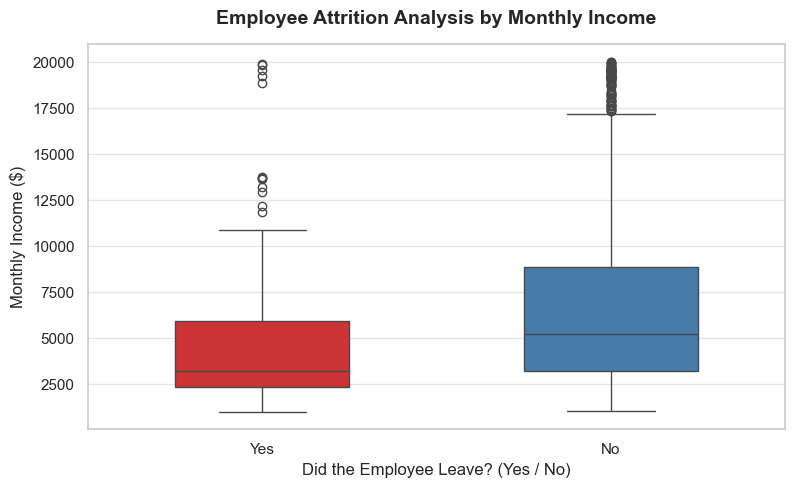

In [5]:

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

#  boxplot comparing monthly income for people who stayed vs left
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, hue='Attrition', palette="Set1", width=0.5, legend=False)

# titles and clear labels
plt.title('Employee Attrition Analysis by Monthly Income', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Did the Employee Leave? (Yes / No)', fontsize=12)
plt.ylabel('Monthly Income ($)', fontsize=12)


plt.savefig('income_vs_attrition_plot.png', dpi=300, bbox_inches='tight')
plt.show()